# RNN Evaluation (Full 1000 Images) - Keras vs Scratch

Notebook ini mengevaluasi seluruh 1000 gambar pada test split untuk membandingkan performa antara implementasi **Keras** dan **NumPy From-Scratch** sesuai spesifikasi tugas IF3270.

In [6]:
import numpy as np
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
import nltk
import sys
import time

nltk.download('wordnet')
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..', '..')))

from src.captioning.common.preprocessing import Tokenizer
from src.captioning.rnn.model import RNNCaptioner
from tensorflow.keras.layers import Input, Dense, Embedding, SimpleRNN, Reshape, Concatenate
from tensorflow.keras.models import Model

[nltk_data] Downloading package wordnet to /Users/Agung/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [7]:
data_dir = "../../../data/flickr8k"
features = np.load(os.path.join(data_dir, "features.npy"))
with open(os.path.join(data_dir, "features_index.json"), 'r') as f:
    features_index = json.load(f)
tokenizer = Tokenizer.load(os.path.join(data_dir, "tokenizer.json"))
with open(os.path.join(data_dir, "splits.json"), 'r') as f:
    splits = json.load(f)

def load_captions(file_path, tokenizer):
    with open(file_path, 'r') as f: lines = f.readlines()[1:]
    mapping = {}
    for line in lines:
        parts = line.split(',', 1)
        if len(parts) < 2: continue
        img_id, cap = parts[0], parts[1].strip()
        if img_id not in mapping: mapping[img_id] = []
        clean_cap = tokenizer.clean_caption(cap)
        words = clean_cap.split()
        mapping[img_id].append(' '.join(words[1:-1]))
    return mapping
ground_truth_captions = load_captions(os.path.join(data_dir, "captions.txt"), tokenizer)

In [8]:
def define_keras_model(vocab_size, max_length, embed_dim, hidden_dim, num_layers=1):
    inputs1 = Input(shape=(2048,))
    fe1 = Dense(embed_dim, activation='relu', name='image_projection')(inputs1)
    fe1_reshaped = Reshape((1, embed_dim))(fe1)
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(inputs2)
    sequence_input = Concatenate(axis=1)([fe1_reshaped, se1])
    x = sequence_input
    for i in range(num_layers):
        x = SimpleRNN(hidden_dim, return_sequences=True, name=f'simple_rnn_{i}')(x)
    outputs = Dense(vocab_size, activation='softmax', name='dense_output')(x)
    return Model(inputs=[inputs1, inputs2], outputs=outputs)

def generate_caption_keras(model, tokenizer, image_feature, max_length):
    in_text = tokenizer.start_token
    for _ in range(max_length):
        sequence = [tokenizer.word_index[w] for w in in_text.split() if w in tokenizer.word_index]
        sequence = np.pad(sequence, (0, max_length - len(sequence)), 'constant', constant_values=tokenizer.word_index[tokenizer.pad_token])
        yhat = model.predict([image_feature, np.array([sequence])], verbose=0)
        curr_step = len(in_text.split())
        word_idx = np.argmax(yhat[0, curr_step])
        word = tokenizer.index_word.get(word_idx, '')
        if word == tokenizer.end_token or word == tokenizer.pad_token:
            break
        in_text += ' ' + word
    return ' '.join(in_text.split()[1:])

In [9]:
configs = [
    {"name": "rnn_1layer_128", "layers": 1, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_1layer_512", "layers": 1, "hidden_dim": 512, "embed_dim": 256},
    {"name": "rnn_2layer_128", "layers": 2, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_2layer_512", "layers": 2, "hidden_dim": 512, "embed_dim": 256},
    {"name": "rnn_3layer_128", "layers": 3, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_3layer_512", "layers": 3, "hidden_dim": 512, "embed_dim": 256}
]

results_full = {}
test_images = splits['test']

print(f"--- TAHAP 1: Evaluasi 6 Variasi RNN (NUMPY SCRATCH - 1000 IMAGES) ---")
for config in configs:
    keras_model = define_keras_model(
        tokenizer.vocab_size, tokenizer.max_length, 
        config['embed_dim'], config['hidden_dim'], config['layers']
    )
    keras_model.load_weights(f"../../../weights/captioning/rnn/{config['name']}.weights.h5")
    model_scratch = RNNCaptioner(
        tokenizer.vocab_size, config['embed_dim'], 
        config['hidden_dim'], tokenizer.max_length, config['layers']
    )
    model_scratch.load_weights_from_keras(keras_model)
    
    actuals, preds = [], []
    meteor_scores = []
    start_time = time.time()
    
    for i, img_id in enumerate(test_images):
        feature = features[features_index[img_id]].reshape(1, -1)
        cap = model_scratch.generate_caption_greedy(feature, tokenizer)
        gt = ground_truth_captions.get(img_id, [])
        actuals.append([g.split() for g in gt])
        p = cap.split()
        preds.append(p)
        best_meteor = max([meteor_score([g.split()], p) for g in gt])
        meteor_scores.append(best_meteor)
        if (i + 1) % 250 == 0: print(f"[{config['name']}] Progress: {i+1}/1000 images...")
            
    exec_time = time.time() - start_time
    bleu4 = corpus_bleu(actuals, preds, weights=(0.25, 0.25, 0.25, 0.25))
    meteor = np.mean(meteor_scores)
    results_full[config['name']] = {'bleu4': bleu4, 'meteor': meteor, 'time': exec_time}
    print(f"DONE: {config['name']:<15} | BLEU-4: {bleu4:.4f} | METEOR: {meteor:.4f} | Time: {exec_time:.2f}s")

--- TAHAP 1: Evaluasi 6 Variasi RNN (NUMPY SCRATCH - 1000 IMAGES) ---
[rnn_1layer_128] Progress: 250/1000 images...
[rnn_1layer_128] Progress: 500/1000 images...
[rnn_1layer_128] Progress: 750/1000 images...
[rnn_1layer_128] Progress: 1000/1000 images...
DONE: rnn_1layer_128  | BLEU-4: 0.0836 | METEOR: 0.2788 | Time: 7.95s
[rnn_1layer_512] Progress: 250/1000 images...
[rnn_1layer_512] Progress: 500/1000 images...
[rnn_1layer_512] Progress: 750/1000 images...
[rnn_1layer_512] Progress: 1000/1000 images...
DONE: rnn_1layer_512  | BLEU-4: 0.0916 | METEOR: 0.2944 | Time: 37.36s
[rnn_2layer_128] Progress: 250/1000 images...
[rnn_2layer_128] Progress: 500/1000 images...
[rnn_2layer_128] Progress: 750/1000 images...
[rnn_2layer_128] Progress: 1000/1000 images...
DONE: rnn_2layer_128  | BLEU-4: 0.1021 | METEOR: 0.2826 | Time: 7.29s
[rnn_2layer_512] Progress: 250/1000 images...
[rnn_2layer_512] Progress: 500/1000 images...
[rnn_2layer_512] Progress: 750/1000 images...
[rnn_2layer_512] Progress:

In [10]:
best_name = max(results_full, key=lambda k: results_full[k]['bleu4'])
best_config = next(c for c in configs if c['name'] == best_name)
print(f"\n--- TAHAP 2: Perbandingan Keras vs Scratch untuk Arsitektur Terbaik ({best_name}) - 1000 IMAGES ---")

keras_model_best = define_keras_model(
    tokenizer.vocab_size, tokenizer.max_length, 
    best_config['embed_dim'], best_config['hidden_dim'], best_config['layers']
)
keras_model_best.load_weights(f"../../../weights/captioning/rnn/{best_config['name']}.weights.h5")

keras_preds, keras_actuals = [], []
start_time = time.time()

for i, img_id in enumerate(test_images):
    feature = features[features_index[img_id]].reshape(1, -1)
    cap = generate_caption_keras(keras_model_best, tokenizer, feature, tokenizer.max_length)
    keras_preds.append(cap.split())
    gt = ground_truth_captions.get(img_id, [])
    keras_actuals.append([g.split() for g in gt])
    if (i + 1) % 100 == 0: print(f"[KERAS EVAL] Progress: {i+1}/1000 images...")

keras_time = time.time() - start_time
keras_bleu = corpus_bleu(keras_actuals, keras_preds, weights=(0.25, 0.25, 0.25, 0.25))

print(f"\nFINAL COMPARISON (1000 IMAGES):")
print(f"BLEU-4 (Scratch): {results_full[best_name]['bleu4']:.4f} | Time: {results_full[best_name]['time']:.2f}s")
print(f"BLEU-4 (Keras):   {keras_bleu:.4f} | Time: {keras_time:.2f}s")


--- TAHAP 2: Perbandingan Keras vs Scratch untuk Arsitektur Terbaik (rnn_2layer_128) - 1000 IMAGES ---
[KERAS EVAL] Progress: 100/1000 images...
[KERAS EVAL] Progress: 200/1000 images...
[KERAS EVAL] Progress: 300/1000 images...
[KERAS EVAL] Progress: 400/1000 images...
[KERAS EVAL] Progress: 500/1000 images...
[KERAS EVAL] Progress: 600/1000 images...
[KERAS EVAL] Progress: 700/1000 images...
[KERAS EVAL] Progress: 800/1000 images...
[KERAS EVAL] Progress: 900/1000 images...
[KERAS EVAL] Progress: 1000/1000 images...

FINAL COMPARISON (1000 IMAGES):
BLEU-4 (Scratch): 0.1021 | Time: 7.29s
BLEU-4 (Keras):   0.1021 | Time: 320.27s



--- ANALISIS KUALITATIF (10 Gambar Pertama) ---


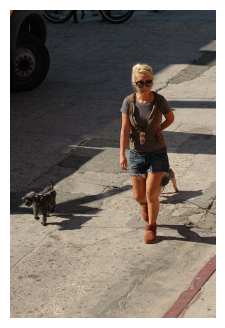

ID: 1685463722_55843b6d3c.jpg
Ground Truths: ['a woman and her two dogs are walking down the street', 'a woman wearing cut off shorts walks down the street with a dog', 'the woman in blue shorts and a brown vest has a black dog to the right of her and a dog behind her', 'the woman is walking her dogs', 'woman and small black dog walking across pavement']
Keras RNN    : a man in a red shirt is standing on a bench
Scratch RNN  : a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


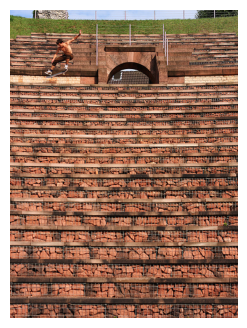

ID: 3718305988_fe2c91fd44.jpg
Ground Truths: ['a jogger runs up brick stairs for streght training', 'a man is skating down a set of stairs', 'a skateboarder jumps on brick stairs', 'a young man skateboards around the empty outdoor sports arena', 'the man is skateboarding on a large brick staircase']
Keras RNN    : a man in a red shirt is standing on a bench
Scratch RNN  : a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


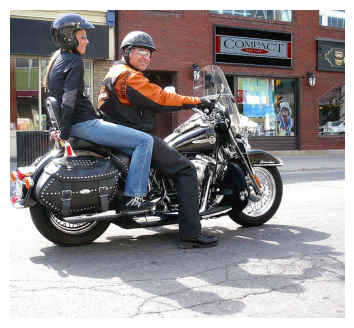

ID: 2439031566_2e0c0d3550.jpg
Ground Truths: ['a couple riding a bike', 'a couple riding down the street on a motorcycle', 'a man and woman sitting on a motorcycle', 'a man sits on a motorcycle and a woman is on the back', 'two people ride together on a black motorcycle']
Keras RNN    : a man in a red shirt is standing on a bench
Scratch RNN  : a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


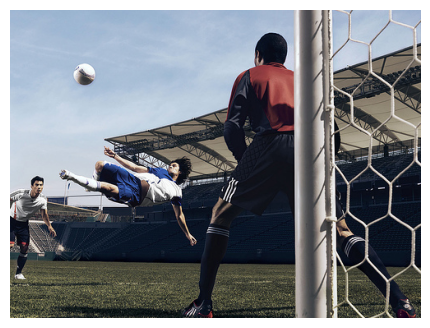

ID: 2887744223_029f2fd5fe.jpg
Ground Truths: ['a man is parallel in the air trying to kick the soccer ball past the goalie', 'a soccer player in white attacks the ball with flying kick towards the goal of the player in red as another team member looks on', 'a soccer player is jumping into the air to kick the soccer ball into the goal', 'a soccer player is making a flying kick towards the goal', 'a soccer player leaps sideways in the air to kick the ball']
Keras RNN    : a dog is running through the water
Scratch RNN  : a dog is running through the water
--------------------------------------------------------------------------------


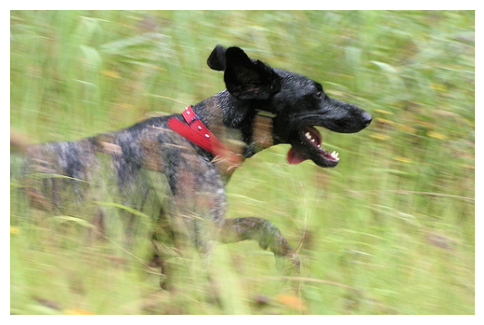

ID: 1311132744_5ffd03f831.jpg
Ground Truths: ['a black and grey dog runs in a field with its tongue hanging out', 'a black dog with a red collar runs through grass', 'a black dog with a red collar walks through the grass with his mouth open and tongue hanging out', 'a dog with a red collar and its tongue hanging out runs through tall grass', 'a dog with red collar is running in the field']
Keras RNN    : a dog is running through the water
Scratch RNN  : a dog is running through the water
--------------------------------------------------------------------------------


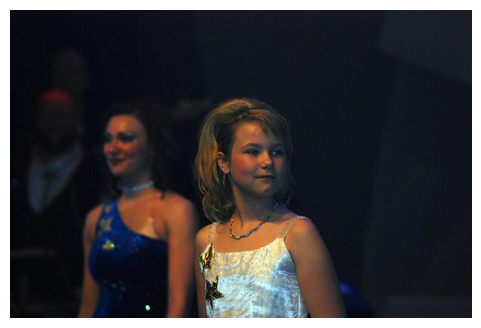

ID: 2396691909_6b8c2f7c44.jpg
Ground Truths: ['a girl in a white dress walks next to a girl in a blue dress', 'a woman in a white dress and a woman in a blue dress onstage', 'a young girl with makeup and jewelry smiles', 'blonde girl in white top with stars standing beside brunette woman in blue top with stars', 'two teenage girls are wearing fancy dresses at an event']
Keras RNN    : a man in a red shirt is standing on a bench
Scratch RNN  : a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


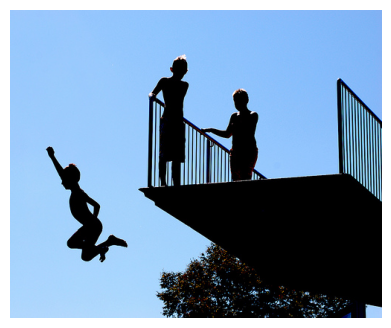

ID: 2789648482_1df61f224a.jpg
Ground Truths: ['a boy jumps off a platform whilst two other boys stand and watch', 'a child is jumping off a platform into a pool', 'three boys jumping off of a platform', 'three children on diving board with one jumping off', 'two boys standing on top of a diving platform and one captured midair']
Keras RNN    : a man in a red shirt is standing on a bench
Scratch RNN  : a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


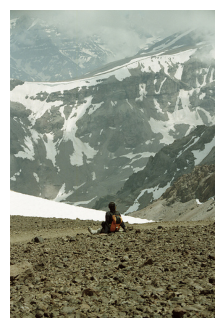

ID: 319870744_0e0138d205.jpg
Ground Truths: ['a hiker is sitting on the ground looking towards the snow covered mountains', 'a man is sitting on top of a mountain', 'a person sits near a mountain', 'one person wearing a backpack sitting on the side of a rocky mountain', 'someone is sitting on a hill overlooking a rocky mountain']
Keras RNN    : a man in a red shirt is standing on a bench
Scratch RNN  : a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


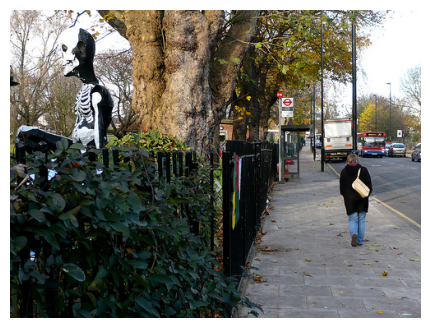

ID: 2065875490_a46b58c12b.jpg
Ground Truths: ['a person is walking on a sidewalk and a skeleton is on the left inside of a fence', 'a skeleton sits on a fence on the edge of a road', 'a skeleton sits on the bushes', 'a woman walks down a sidewalk past a halloween decoration', 'there is a large skeleton behind a fence']
Keras RNN    : a man in a red shirt is standing on a bench
Scratch RNN  : a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


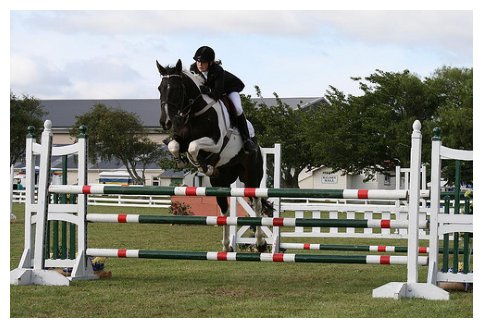

ID: 3516935867_78cf63c69c.jpg
Ground Truths: ['a black horse and its rider are clearing a 3 rung high jump in a competition', 'a horse and rider leap over a striped hurdle', 'a person is riding a horse as it jumps over an obstacle', 'a person jumping a horse over a fence', 'a rider and horse jumping a fence outdoors']
Keras RNN    : a dog is running through the water
Scratch RNN  : a dog is running through the water
--------------------------------------------------------------------------------


In [11]:
# ANALISIS KUALITATIF (10 Gambar Pertama)
print("\n--- ANALISIS KUALITATIF (10 Gambar Pertama) ---")
for img_id in test_images[:10]:
    feature = features[features_index[img_id]].reshape(1, -1)
    
    # Prediksi Keras
    cap_keras = generate_caption_keras(keras_model_best, tokenizer, feature, tokenizer.max_length)
    
    # Prediksi Scratch (Arsitektur Terbaik)
    model_scratch_best = RNNCaptioner(
        tokenizer.vocab_size, best_config['embed_dim'], 
        best_config['hidden_dim'], tokenizer.max_length, best_config['layers']
    )
    model_scratch_best.load_weights_from_keras(keras_model_best)
    cap_scratch = model_scratch_best.generate_caption_greedy(feature, tokenizer)
    
    gt = ground_truth_captions.get(img_id, [])
    
    # Tampilkan Gambar
    img_path = os.path.join(data_dir, "images", img_id)
    if os.path.exists(img_path):
        plt.figure(figsize=(6, 4))
        img = Image.open(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
    print(f"ID: {img_id}")
    print(f"Ground Truths: {gt}")
    print(f"Keras RNN    : {cap_keras}")
    print(f"Scratch RNN  : {cap_scratch}")
    print("-" * 80)